## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
!hostname

ne1dc4-034.nygenome.org


In [2]:
import os
import pandas as pd 
from sklearn.decomposition import TruncatedSVD
import anndata as ad
from scipy.sparse import coo_matrix, csr_matrix
from datetime import datetime

# turn this into AnnData object 
import anndata as ad
import numpy as np
import torch 
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from scipy.spatial.distance import cdist

import numpy as np

import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
import scipy.sparse
import datetime
import sys
import random

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
# from visualize_ATSE import visualize_local_events

# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import BetaDirichletFactor.waypoints as wayp

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

!hostname

Torch Version: 2.4.1.post300
CUDA Version: 12.0
Using device: cpu
ne1dc4-034.nygenome.org


### Load input files 


In [3]:
input_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/junction_processing_20250415/anndatas/merged_anndata.h5ad"
splice_adata = ad.read_h5ad(input_file)
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index 
print(f"The number of cells in the dataset is {splice_adata.shape[0]}")

ATSE_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-16_09-46-32.txt.gz"
atses = pd.read_csv(ATSE_file, sep="\t")
print(f"The number of ATSEs in this dataset is {len(atses['event_id'].unique())}")

The number of cells in the dataset is 160506
The number of ATSEs in this dataset is 17826


In [4]:
# fill in missing "age" values with "unknown_atm" not these are currently categorical 
splice_adata.obs["age"].value_counts()

age
       54324
3m     41739
18m    33128
24m    31315
Name: count, dtype: int64

##### Clean up Cell IDs in the splicing Anndata object so can merge them with the IDs in the gene expression object

In [ ]:
metadata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/metadata_mouse_metadata_combined.csv"
metadata = pd.read_csv(metadata)
metadata.tail()
splice_adata.obs = splice_adata.obs.drop(columns=["age", "cell_ontology_class", "mouse.id", "sex", "subtissue", "tissue"])

,cell_id,age,cell_ontology_class,mouse.id,sex,subtissue,tissue
180126,SRR16459076,2m,197_L5 IT CTX,366890,F,VISp,SM-GE676_S087_E1-50
180127,SRR16459078,2m,197_L5 IT CTX,366890,F,VISp,SM-GE676_S089_E1-50
180128,SRR16459085,2m,257_L5 PT CTX,366890,F,VISp,SM-GE676_S095_E1-50
180129,SRR16459086,2m,197_L5 IT CTX,366890,F,VISp,SM-GE676_S096_E1-50
180130,SRR16459090,2m,204_L5/6 IT CTX,366890,F,VISp,SM-GE676_S100_E1-50


In [12]:
# subset splice_adata to just cell_id in metadata 
splice_adata = splice_adata[splice_adata.obs["cell_id"].isin(metadata["cell_id"])]
print(f"The number of cells in the dataset is {splice_adata.shape[0]}")

The number of cells in the dataset is 157426


In [13]:
splice_adata.obs = splice_adata.obs.merge(metadata, on = "cell_id")
# renumber the cell_id_index
splice_adata.obs["cell_id_index"] = range(len(splice_adata.obs))

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [15]:
splice_adata.obs["dataset"] = "TMS"
# if age is 2m then change dataset to AB 
splice_adata.obs.loc[splice_adata.obs["age"] == "2m", "dataset"] = "AB"
splice_adata.obs.dataset.value_counts()

dataset
TMS    106182
AB      51244
Name: count, dtype: int64

In [16]:
# Set the source based on whether 'age' is an empty string or not
splice_adata.obs["source"] = "AB"
splice_adata.obs.loc[splice_adata.obs["age"] != "", "source"] = "TMS"

# Assign sequencing technology based on source
splice_adata.obs["seqtech"] = "single_nuclei"
splice_adata.obs.loc[splice_adata.obs["source"] == "TMS", "seqtech"] = "single_cell"

# Clean cell_id only for TMS cells
splice_adata.obs["cell_clean"] = splice_adata.obs["cell_id"]
is_tms = splice_adata.obs["source"] == "TMS"
splice_adata.obs.loc[is_tms, "cell_clean"] = (
    splice_adata.obs.loc[is_tms, "cell_id"]
    .str.replace(r'-(?=.*_)', '_', regex=True)
    .str.split('_')
    .str[:2]
    .str.join('_')
)

print(f"The number of cells in the dataset is {splice_adata.shape[0]}")

The number of cells in the dataset is 157426


#### Figure out which junctions to include for model training object

In [17]:
splice_adata.var["non_zero_count_cells"] = np.array((splice_adata.X > 0).sum(axis=0)).flatten()
splice_adata.var["non_zero_cell_prop"] = splice_adata.var["non_zero_count_cells"] / splice_adata.shape[0]

In [18]:
# let's make an ATSE event id score to decide which ATSEs to keep at the end, since we are limited to under 100,000 splice junctions 
# what do we care about? 
# - number of fully annotated splice junctions in the ATSE vs partially annotated vs unannotated (annotation_status)
# - number of cells that have splice junctions in this ATSE expressed above zero (non_zero_cell_prop)
# - which splice_motif is used in the ATSE (splice_motif)

# let's make a score for each ATSE based on these three criteria 
# - annotation_status: 1 for fully annotated, 0.5 for partially annotated, 0 for unannotated
# - non_zero_cell_prop: 1 if non_zero_cell_prop > 0.01, 0 otherwise
# - splice_motif: 1 if splice_motif is "GT-AG", 0 otherwise

# let's calculate these for every junction and combine and normalize score per ATSE event_id 
splice_adata.var["annotation_status_score"] = splice_adata.var["annotation_status"].map({"both": 1, "five_prime": 0.5, "three_prime": 0.5, "unannotated": 0})
splice_adata.var["non_zero_cell_prop_score"] = (splice_adata.var["non_zero_cell_prop"] > 0.01).astype(int)
splice_adata.var["splice_motif_score"] = (splice_adata.var["splice_motif"] == "GT-AG").astype(int)

# weigh the annotation_status_score more heavily than the other two scores 
splice_adata.var["annotation_status_score"] *= 2
splice_adata.var["non_zero_cell_prop_score"] *= 1.5

# Combine and normalize score per ATSE event_id 
# First group by event_id and sum the scores before normalizing by the number of junctions in the event_id
atse_scores = splice_adata.var.groupby("event_id")[
    ["annotation_status_score", "non_zero_cell_prop_score"]
].sum()

# Normalize by the number of junctions in each event_id
junction_counts = splice_adata.var["event_id"].value_counts().rename("junction_count")

# Add the three columns to make ATSE_score 
atse_scores["atse_score"] = atse_scores.sum(axis=1)
atse_scores["number_of_junctions"] = junction_counts
atse_scores["normalized_atse_score"] = atse_scores["atse_score"] / junction_counts
atse_scores.sort_values("number_of_junctions", ascending=False).head()

/scratch/ipykernel_4003757/4098449752.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  atse_scores = splice_adata.var.groupby("event_id")[


,annotation_status_score,non_zero_cell_prop_score,atse_score,number_of_junctions,normalized_atse_score
event_id,,,,,
ATSE_16084,0.0,0.0,0.0,49,0.000000
ATSE_4408,0.0,1.5,1.5,38,0.039474
ATSE_1090,0.0,55.5,55.5,37,1.500000
ATSE_16918,38.0,27.0,65.0,32,2.031250
ATSE_1710,27.0,36.0,63.0,27,2.333333


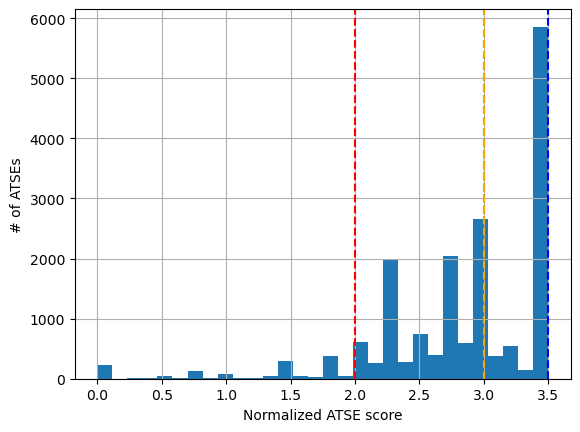

Number of ATSEs remaining at 10th percentile: 15882
Number of ATSEs remaining at 50th percentile: 6916
Number of ATSEs remaining at 60th percentile: 6916
Number of ATSEs remaining at 90th percentile: 0


In [19]:
# summarize histogram of normalized_atse_score show percentilues 10% 50% 90% 
atse_scores["normalized_atse_score"].describe(percentiles=[0.1, 0.5, 0.6, 0.9])
# make a histogram of the normalized_atse_score 
atse_scores["normalized_atse_score"].hist(bins=30)

# draw dashed lines for the percentiles 
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.1), color="red", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.5), color="green", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.6), color="orange", linestyle="--")
plt.axvline(atse_scores["normalized_atse_score"].quantile(0.9), color="blue", linestyle="--")

# add xlaxis and yaxis labels 
plt.xlabel("Normalized ATSE score")
plt.ylabel("# of ATSEs")
plt.show()

# Print how many ATSEs remain after filtering at each of the percentiles
print(f"Number of ATSEs remaining at 10th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.1)].shape[0]}")
print(f"Number of ATSEs remaining at 50th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.5)].shape[0]}")
print(f"Number of ATSEs remaining at 60th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.6)].shape[0]}")
print(f"Number of ATSEs remaining at 90th percentile: {atse_scores[atse_scores['normalized_atse_score'] > atse_scores['normalized_atse_score'].quantile(0.9)].shape[0]}")


In [20]:
# For splice_adata object, let's filter out the ATSEs that have a normalized_atse_score below the 10th percentile
atse_scores_filt = atse_scores[atse_scores["normalized_atse_score"] > atse_scores["normalized_atse_score"].quantile(0.1)]
print(f"Number of ATSEs remaining after filtering: {atse_scores_filt.shape[0]}")

Number of ATSEs remaining after filtering: 15882


In [21]:
splice_adata = splice_adata[:, splice_adata.var["event_id"].isin(atse_scores_filt.index)]
# print remaining number of atses 
print(f"The number of junctions in the dataset is {splice_adata.shape[1]}")

The number of junctions in the dataset is 47858


In [22]:
# find common columns between splice_adata.var and atses
splice_adata.var = splice_adata.var.merge(atses[["gene_id", "gene_name", "junction_id", "annotation_status", "position_off_5_prime", "position_off_3_prime"]], on=["junction_id", "gene_id", "annotation_status", "gene_name", "position_off_5_prime", "position_off_3_prime"])

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [23]:
splice_adata.var.reset_index(drop=True, inplace=True)
# Rename the old junction_id_index to old_junction_id_index 
splice_adata.var.rename(columns={'junction_id_index': 'old_junction_id_index'}, inplace=True)
# Redo the junction_id_index column now that we have removed some junctions
splice_adata.var['junction_id_index'] = splice_adata.var.index
splice_adata.var.head()

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,junction_id_index
0,chr10_100016035_100051845_+,ATSE_11911,GT-AG,both,Kitl,ENSMUSG00000019966.18,2,0.0,1.0,211210,0,11228,0.071322,2.0,1.5,1,0
1,chr10_100016155_100051845_+,ATSE_11911,GT-AG,both,Kitl,ENSMUSG00000019966.18,2,0.0,1.0,5194,1,771,0.004898,2.0,0.0,1,1
2,chr10_100080130_100080856_+,ATSE_11912,GT-AG,both,Kitl,ENSMUSG00000019966.18,3,0.0,1.0,199659,2,10236,0.065021,2.0,1.5,1,2
3,chr10_100080130_100087346_+,ATSE_11912,GT-AG,both,Kitl,ENSMUSG00000019966.18,3,0.0,1.0,111965,3,2612,0.016592,2.0,1.5,1,3
4,chr10_100080940_100087346_+,ATSE_11912,GT-AG,both,Kitl,ENSMUSG00000019966.18,3,0.0,1.0,180991,4,10011,0.063592,2.0,1.5,1,4


### Code for doing sanity check to ensure correct counts are stored in combined Anndata object across cell-junctions

In [24]:
# to-do... just in case especially now that looking across two different datasets 

### Clean up tissue and cell_type grouping names

In [25]:
# Dictionary to consolidate duplicates
subtissue_corrections = {
    'T cells': 'T-cells',
    'ENDOMUCIN': 'Endomucin',
    'forelimb and hindlimb': 'ForelimbandHindlimb',
    'Liver non-hepato/SCs_st': 'Liver non-hepato/SCs',
    'Skin Anagen': 'Anagen'
}

cell_type_groupings = {
    
    # Basal cells
    'basal cell of epidermis': 'BASAL CELL',
    'basal cell': 'BASAL CELL',

    # Endothelial cells
    'endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of coronary artery': 'ENDOTHELIAL CELL',
    'endothelial cell of hepatic sinusoid': 'ENDOTHELIAL CELL',
    'aortic endothelial cell': 'ENDOTHELIAL CELL',
    'vein endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of lymphatic vessel': 'ENDOTHELIAL CELL',

    # T cells
    'T cell': 'T CELL',
    'CD4-positive, alpha-beta T cell': 'T CELL',
    'CD8-positive, alpha-beta T cell': 'T CELL',
    'regulatory T cell': 'T CELL',
    'mature NK T cell': 'T CELL',
    'mature alpha-beta T cell': 'T CELL',
    
    # B cells
    'B cell': 'B CELL',
    'immature B cell': 'B CELL',
    'naive B cell': 'B CELL',
    'precursor B cell': 'B CELL',
    'early pro-B cell': 'B CELL',
    'late pro-B cell': 'B CELL',
    'plasma cell': 'B CELL',

    # Fibroblasts
    'fibroblast': 'FIBROBLAST',
    'fibroblast of cardiac tissue': 'FIBROBLAST',
    'fibroblast of lung': 'FIBROBLAST',
    'pulmonary interstitial fibroblast': 'FIBROBLAST',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'fibrocyte': 'FIBROBLAST',

    # Macrophages 
    'macrophage': 'MACROPHAGE',
    'Kupffer cell': 'MACROPHAGE', # macrophages in the liver
    'lung macrophage': 'MACROPHAGE',

    # Monocytes
    'monocyte': 'MONOCYTE',
    'classical monocyte': 'MONOCYTE',
    'non-classical monocyte': 'MONOCYTE',
    'intermediate monocyte': 'MONOCYTE',

    # General Immune Cells
    'granulocyte': 'GRANULOCYTE',
    'basophil': 'GRANULOCYTE', 
    'granulocyte monocyte progenitor cell': 'GRANULOCYTE',

    'leukocyte': 'GENERAL IMMUNE CELL',
    'professional antigen presenting cell': 'ANTIGEN PRESENTING CELL',

    'lymphocyte': 'LYMPHOID IMMUNE CELL',
    'NK cell': 'LYMPHOID IMMUNE CELL',

    'myeloid cell': 'MYELOID IMMUNE CELL',
    'myeloid leukocyte': 'MYELOID IMMUNE CELL',
    'granulocytopoietic cell': 'MYELOID IMMUNE CELL',
    'promonocyte': 'MYELOID IMMUNE CELL',

    'thymocyte': 'THYMOCYTE',
    'DN4 thymocyte': 'THYMOCYTE',

    # Neutrophils
    'neutrophil': 'NEUTROPHIL',

    # Dendritic Cells
    'dendritic cell': 'DENDRITIC CELL',
    'plasmacytoid dendritic cell': 'DENDRITIC CELL',
    'myeloid dendritic cell': 'DENDRITIC CELL',

    # Microglia (Brain Immune Cells)
    'microglial cell': 'MICROGLIA',
    
    # Pancreatic cells
    'pancreatic A cell': 'PANCREATIC CELL',
    'pancreatic B cell': 'PANCREATIC CELL',
    'pancreatic D cell': 'PANCREATIC CELL',
    'pancreatic acinar cell': 'PANCREATIC CELL',
    'pancreatic PP cell': 'PANCREATIC CELL',
    'pancreatic ductal cell': 'PANCREATIC CELL',
    'pancreatic stellate cell': 'PANCREATIC CELL',
    
    # Smooth muscle cells
    'smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'bronchial smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of the pulmonary artery': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of trachea': 'SMOOTH MUSCLE CELL',
    
    # Epithelial cells (includes luminal epithelial cell of mammary gland)
    'epithelial cell': 'EPITHELIAL CELL',
    'epidermal cell': 'EPITHELIAL CELL',
    'epithelial cell of large intestine': 'EPITHELIAL CELL',
    'enterocyte of epithelium of large intestine': 'EPITHELIAL CELL',
    'epithelial cell of proximal tubule': 'EPITHELIAL CELL',
    'epithelial cell of thymus': 'EPITHELIAL CELL',
    'bladder urothelial cell': 'EPITHELIAL CELL',
    'basal epithelial cell of tracheobronchial tree': 'EPITHELIAL CELL',
    'luminal epithelial cell of mammary gland': 'EPITHELIAL CELL',

    # Neurons
    'neuron': 'NEURON',
    'medium spiny neuron': 'NEURON',
    'interneuron': 'NEURON',
    'neuronal stem cell': 'NEURON',

    # Glial Cells (excluding microglia)
    'oligodendrocyte': 'GLIAL CELL',
    'oligodendrocyte precursor cell': 'GLIAL CELL',
    'astrocyte': 'GLIAL CELL',
    'Bergmann glial cell': 'GLIAL CELL',
    'ependymal cell': 'GLIAL CELL',

    # Stem cells
    'mesenchymal stem cell': 'STEM CELL',
    'mesenchymal stem cell of adipose': 'STEM CELL',
    'hematopoietic stem cell': 'STEM CELL',
    'neuronal stem cell': 'STEM CELL',
    'intestinal crypt stem cell': 'STEM CELL',
    'keratinocyte stem cell': 'STEM CELL',
    'lymphoid progenitor cell': 'STEM CELL',
    'proerythroblast': 'STEM CELL',
    'megakaryocyte-erythroid progenitor cell': 'STEM CELL',

    # Other specialized cells
    'ventricular myocyte': 'CARDIAC MUSCLE CELL',
    'atrial myocyte': 'CARDIAC MUSCLE CELL',
    'skeletal muscle satellite cell': 'SKELETAL MUSCLE CELL',
    'kidney collecting duct principal cell': 'KIDNEY CELL',
    'kidney collecting duct epithelial cell': 'KIDNEY CELL',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'mesangial cell': 'KIDNEY CELL',
    'type I pneumocyte': 'LUNG CELL',
    'type II pneumocyte': 'LUNG CELL',
    'club cell of bronchiole': 'LUNG CELL',
    'lung neuroendocrine cell': 'LUNG CELL',
    'ciliated columnar cell of tracheobronchial tree': 'LUNG CELL',
    'respiratory basal cell': 'LUNG CELL',
    'Brush cell of epithelium proper of large intestine': 'INTESTINAL CELL',
    'large intestine goblet cell': 'INTESTINAL CELL',
    'enteroendocrine cell': 'INTESTINAL CELL',
    'stromal cell': 'STROMAL CELL',
    'pericyte cell': 'PERICYTE',
    'brain pericyte': 'PERICYTE',
    'adventitial cell': 'STROMAL CELL',
    'keratinocyte': 'KERATINOCYTE',
    'bulge keratinocyte': 'KERATINOCYTE',
    'hepatocyte': 'HEPATOCYTE',
    'bladder cell': 'BLADDER CELL',
    'secretory cell': 'SECRETORY CELL',
    'endocardial cell': 'ENDOCARDIAL CELL',
    'valve cell': 'VALVE CELL',
    'chondrocyte': 'STROMAL CELL',
    'fenestrated cell': 'FENESTRATED CELL',
    'neuroepithelial cell': 'NEUROEPITHELIAL CELL',
    'kidney loop of Henle ascending limb epithelial cell': 'KIDNEY CELL',
    'mucus secreting cell': 'SECRETORY CELL'
}

In [26]:
# Remove any leading/trailing whitespace from subtissue values
splice_adata.obs['subtissue'] = splice_adata.obs['subtissue'].str.strip()
splice_adata.obs['subtissue_clean'] = splice_adata.obs['subtissue'].replace(subtissue_corrections)

# Drop the old subtissue 
splice_adata.obs.drop(columns=['subtissue'], inplace=True)

# Add new cell type groupings 
splice_adata.obs['cell_ontology_class'] = splice_adata.obs['cell_ontology_class'].astype(str)
splice_adata.obs['cell_type_grouped'] = splice_adata.obs['cell_ontology_class'].replace(cell_type_groupings)
print(f"The number of cells in the splicing dataset is {splice_adata.shape[0]}")

The number of cells in the splicing dataset is 157426


### Subset to just cell types with more than 10 cells in them

In [27]:
# Step 1: Count the number of cells per cell type in 'cell_ontology_class'
cell_type_counts = splice_adata.obs['cell_type_grouped'].value_counts()

# Step 2: Filter for cell types with more than 50 cells
cell_types_to_keep = cell_type_counts[cell_type_counts > 1].index

# Step 3: Subset the AnnData object to only include these cell types
splice_adata = splice_adata[splice_adata.obs['cell_type_grouped'].isin(cell_types_to_keep)]

# Print the subsetted cell types and their counts
print(splice_adata.obs['cell_type_grouped'].value_counts())

cell_type_grouped
MICROGLIA              12795
STEM CELL              10945
B CELL                 10220
ENDOTHELIAL CELL        8696
EPITHELIAL CELL         7712
                       ...  
211_L5/6 IT TPE-ENT        3
172_L2/3 IT ProS           2
369_Oligo                  2
174_IT HATA                2
353_CA3-ve                 2
Name: count, Length: 413, dtype: int64


### Obtain sparse junction usage ratios! (First filter to keep only junctions with reasonable coverage...)

In [28]:
# Print final number of splice junctions, ATSEs, and genes in splice_adata
print(f"Number of splice junctions: {splice_adata.shape[1]}")
print(f"Number of ATSEs: {splice_adata.var['event_id'].nunique()}")

Number of splice junctions: 47858
Number of ATSEs: 15882


In [29]:
print(splice_adata.var.splice_motif.value_counts())
print(splice_adata.var.annotation_status.value_counts())

splice_motif
GT-AG    47354
GC-AG      494
AT-AC       10
Name: count, dtype: int64
annotation_status
both           41319
five_prime      3291
three_prime     3160
unannotated       88
Name: count, dtype: int64


In [30]:
# Update junction_counts and cluster_counts
junction_counts = splice_adata.layers["cell_by_junction_matrix"].tocoo()
cluster_counts = splice_adata.layers["cell_by_cluster_matrix"].tocoo()

#### Get sparse PCA, UMAP and Diffusion Map!

In [ ]:
splice_adata

View of AnnData object with n_obs × n_vars = 157421 × 47858
    obs: 'cell_id', 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'source', 'seqtech', 'cell_clean', 'subtissue_clean', 'cell_type_grouped'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'old_junction_id_index', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'splice_motif_score', 'junction_id_index'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix'

: 

In [ ]:
# Get sparse centered PSI values 
splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)
print(f"Done getting sparse centered PSI values!")

# Step 1: Perform PCA using sparse data
n_components = 30  
svd = TruncatedSVD(n_components=n_components, random_state=42)

# Fit and transform the junction ratio data (this gives U)
U = svd.fit_transform(splice_adata.layers["junc_ratio"])
print(f"Done calculating SVD!")

# Get the singular values (S)
S = svd.singular_values_

# Multiply U by S to get U * S
U_by_S = U * S  # This scales each component in U by the corresponding singular value in S

# Store the PCA results (U * S) in the 'X_pca' field of .obsm (multi-dimensional)
splice_adata.obsm['X_pca'] = U_by_S

# store explained variance ratio for future reference
splice_adata.uns['pca_explained_variance_ratio'] = svd.explained_variance_ratio_
print(svd.explained_variance_ratio_)

In [ ]:
# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(splice_adata, use_rep='X_pca')

# Step 3. Calculate UMAP 
sc.tl.umap(splice_adata)

In [ ]:
# plot UMAP with cell types and age groups
sc.pl.umap(splice_adata, color="seqtech", title="UMAP of Data Source")

### Identify cell waypoints using splicing based PCs!

In [ ]:
# Define possible number of waypoints to learn
n_waypoints_learn = [40]

# Placeholder to store waypoints and metacell dictionaries for each n_waypoints
waypoints_dict = {}
metacell_dicts = {}

# Parameters
num_components = 20  # Number of components to consider
metacell_size = 50    # Number of nearest cells to assign to each waypoint
pca_components = splice_adata.obsm["X_pca"]

# Loop over different n_waypoints to generate waypoints and metacell assignments
for n_waypoints in n_waypoints_learn:

    print(f"Finding {n_waypoints} waypoints from the PCA components!")
    random_seed = np.random.randint(0, 10000 + 1)  # Generate random seed
    
    # Max-min sampling to identify waypoints
    waypoints = wayp.max_min_sampling(pca_components, n_waypoints, num_components=num_components, seed=random_seed)
    
    # Store waypoints for this particular number of waypoints
    waypoints_dict[n_waypoints] = waypoints

    # Assign nearest cells to each waypoint (metacells)
    metacell_dict = wayp.assign_nearest_cells(waypoints, pca_components, num_nearest=metacell_size)
    
    # Store the metacell dictionary for this number of waypoints
    metacell_dicts[n_waypoints] = metacell_dict

#### Try looking at waypoints just using PC space...

In [ ]:
wayp.plot_PCA_with_waypoints(splice_adata, waypoints_dict, n_waypoints=40, waypoint_color='red', first_waypoint_color='blue', size=10)

### Generate_initializations matrices for Phi and Psi

In [ ]:
rho_hat = splice_adata.layers["junc_ratio"]

# Generate multiple initializations
psi_initializations, phi_initializations = wayp.generate_initializations(rho_hat, waypoints_dict, metacell_dicts, epsilon=0.001)

In [ ]:
# Loop through the waypoints_dict and corresponding initializations
for i, n_waypoints in enumerate(waypoints_dict.keys()):

    print(f"Adding waypoint based initializations to anndata for {n_waypoints} waypoints!")

    # Extract the corresponding psi and phi initializations
    psi = psi_initializations[i]
    phi = phi_initializations[i]

    # Convert psi and phi to torch tensors if needed
    psi = torch.tensor(psi)
    phi = torch.tensor(phi)

    # Convert to NumPy arrays if psi and phi are torch tensors (just in case)
    if isinstance(psi, torch.Tensor):
        psi = psi.cpu().numpy()  # Convert to NumPy array
    if isinstance(phi, torch.Tensor):
        phi = phi.cpu().numpy()  # Convert to NumPy array

    # Store psi in `adata.varm` and phi in `adata.obsm` with keys based on the number of waypoints
    splice_adata.varm[f'psi_init_{n_waypoints}_waypoints'] = psi  # Store psi with name 'psi_init_{n_waypoints}_waypoints'
    splice_adata.obsm[f'phi_init_{n_waypoints}_waypoints'] = phi  # Store phi with name 'phi_init_{n_waypoints}_waypoints'


In [ ]:
# remove junc_ratio layer from splice_adata to save memory prior to saving object 
splice_adata.layers.pop("junc_ratio")

### Save splice_adata Anndata object

In [ ]:
# remove first old_junction_id_index column from splice_adata.var
splice_adata.var.drop(columns=['old_junction_id_index'], inplace=True)

In [ ]:
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# Output DIR 
output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/042025"

# in file name include timestamp 
new_filename = f"MOUSE_SPLICING_FOUNDATION_Anndata_ATSE_counts_with_waypoints_{timestamp}.h5ad"

# Create the new full file path
new_file_path = os.path.join(output_dir, new_filename)

# Save the AnnData object with the new filename
splice_adata.write_h5ad(new_file_path, compression='gzip')

print(f"AnnData saved as {new_file_path}")